Test train split
- Similar ratios for Female with

In [69]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split

In [70]:

df_baseline = pd.read_csv("../data/processed/cardio_baseline_clean.csv")
df_feature_1 = pd.read_csv("../data/processed/cardio_bsa_pp.csv")

# Create a new column for stratification by combining 'cardio' and 'gender' columns
df_baseline["stratify"] = df_baseline["cardio"].astype(str) + "_" + df_baseline["gender"].astype(str)
df_feature_1["stratify"] = df_feature_1["cardio"].astype(str) + "_" + df_feature_1["gender"].astype(str)


# Split the data into training and testing sets with stratification


# Split feature engineered dataset

train_df, test_df = train_test_split(
    df_baseline,
    test_size=0.2,
    stratify=df_baseline["stratify"],
    random_state=42,
)

# Second split: carve out validation set from training data
train_df, val_df = train_test_split(
    train_df,
    test_size=0.2,  # 20% of the 80% = 16% of total, giving roughly 64/16/20
    stratify=train_df["stratify"],
    random_state=42,
)

# Save all three
train_df.to_csv("../data/test_train_val_sets/cardio_baseline_train.csv", index=False)
val_df.to_csv("../data/test_train_val_sets/cardio_baseline_val.csv", index=False)
test_df.to_csv("../data/test_train_val_sets/cardio_baseline_test.csv", index=False)


train_df_feat_1, test_df_feat_1 = train_test_split(
    df_feature_1,
    test_size=0.2,
    stratify=df_feature_1["stratify"],
    random_state=42,
)

train_df_feat_1, val_df_feat_1 = train_test_split(
    train_df_feat_1,
    test_size=0.2,  # 20% of the 80% = 16% of total, giving roughly 64/16/20
    stratify=train_df_feat_1["stratify"],
    random_state=42,
)

train_df_feat_1.to_csv("../data/test_train_val_sets/cardio_bsapp_train.csv", index=False)
val_df_feat_1.to_csv("../data/test_train_val_sets/cardio_bsapp_val.csv", index=False)
test_df_feat_1.to_csv("../data/test_train_val_sets/cardio_bsapp_test.csv", index=False)
# print(test_df.columns)
# Compare Proportions of 'stratify' in the full dataset, training set, and testing set
# full_prop  = df_baseline["stratify"].value_counts(normalize=True).sort_index()
# train_prop = train_df["stratify"].value_counts(normalize=True).sort_index()
# test_prop  = test_df["stratify"].value_counts(normalize=True).sort_index()


# comparison_table = pd.concat([full_prop, train_prop, test_prop], axis=1)
# comparison_table.columns = ["Full Dataset", "Train Set", "Test Set"]
# # print(comparison_table)


# # Calculate the counts of each stratification group in the full dataset : For reference
# female_neg = df_baseline[df_baseline["stratify"] == "0_0"].shape[0]
# female_pos = df_baseline[df_baseline["stratify"] == "1_0"].shape[0]
# male_neg   = df_baseline[df_baseline["stratify"] == "0_1"].shape[0]
# male_pos   = df_baseline[df_baseline["stratify"] == "1_1"].shape[0]


# print(f"Females cardio=0: {female_neg}")
# print(f"Females cardio=1: {female_pos}")
# print(f"Female neg/pos ratio: {female_neg/female_pos if female_pos else 'inf'}")

# print(f"Males cardio=0: {male_neg}")
# print(f"Males cardio=1: {male_pos}")
# print(f"Male neg/pos ratio: {male_neg/male_pos if male_pos else 'inf'}")

# print(df_baseline["stratify"].value_counts())
# print(df_baseline["stratify"].value_counts(normalize=True))

In [71]:
def split_dataset(csv_path, save_prefix=None, test_size=0.2, val_size=0.2, random_state=42):
    """
    Loads a CSV, creates stratified train/val/test splits.
    
    Args:
        csv_path    : path to CSV file
        save_prefix : if provided, saves CSVs with this prefix
                      e.g. "cardio_baseline" → saves cardio_baseline_train.csv etc
                      if None, just returns the dataframes
        test_size   : proportion for test set (default 0.2)
        val_size    : proportion of train for val (default 0.2 → ~16% of total)
        random_state: random seed (default 42)
    
    Returns:
        train_df, val_df, test_df
    """
    df = pd.read_csv(csv_path)
    
    # Stratify by cardio + gender
    df["stratify"] = df["cardio"].astype(str) + "_" + df["gender"].astype(str)
    
    # First split — test
    train_df, test_df = train_test_split(
        df,
        test_size=test_size,
        stratify=df["stratify"],
        random_state=random_state,
    )
    
    # Second split — validation from train
    train_df, val_df = train_test_split(
        train_df,
        test_size=val_size,
        stratify=train_df["stratify"],
        random_state=random_state,
    )
    
    print(f"Dataset    : {csv_path}")
    print(f"Total rows : {len(df)}")
    print(f"Train      : {len(train_df)} ({len(train_df)/len(df)*100:.1f}%)")
    print(f"Val        : {len(val_df)}   ({len(val_df)/len(df)*100:.1f}%)")
    print(f"Test       : {len(test_df)}  ({len(test_df)/len(df)*100:.1f}%)")
    print(f"Stratify proportions match: "
          f"{df['stratify'].value_counts(normalize=True).round(3).to_dict()}")
    
    # Save if prefix provided
    if save_prefix:
        train_df.to_csv(f"../data/test_train_val_sets/{save_prefix}_train.csv", index=False)
        val_df.to_csv(f"../data/test_train_val_sets/{save_prefix}_val.csv",   index=False)
        test_df.to_csv(f"../data/test_train_val_sets/{save_prefix}_test.csv", index=False)
        print(f"\nSaved to ../data/test_train_val_sets/{save_prefix}_*.csv")
    
    return train_df, val_df, test_df

In [72]:
# # Just get the dataframes
# train_df, val_df, test_df = split_dataset(
#     "../data/processed/cardio_baseline_clean.csv"
# )

# # Get dataframes AND save
# train_df, val_df, test_df = split_dataset(
#     "../data/processed/cardio_baseline_clean.csv",
#     save_prefix="cardio_baseline"
# )

# # Feature engineered dataset
# train_fe, val_fe, test_fe = split_dataset(
#     "../data/processed/cardio_bsa_pp.csv",
#     save_prefix="cardio_bsapp"
# )

In [73]:
# pretty_table = comparison_table.copy()

# # Rename rows to be readable
# label_map = {
#     "0_0": "Female – No CVD",
#     "1_0": "Female – CVD",
#     "0_1": "Male – No CVD",
#     "1_1": "Male – CVD",
# }

# pretty_table.index = pretty_table.index.map(label_map)

# # Convert to percentages
# pretty_table = (pretty_table * 100).round(2)

# print("\nStratified Proportions (%)")
# print(pretty_table)
# balance_table = pd.DataFrame({
#     "Cardio = 0": [female_neg, male_neg],
#     "Cardio = 1": [female_pos, male_pos],
#     "Neg/Pos Ratio": [
#         round(female_neg / female_pos, 3),
#         round(male_neg / male_pos, 3)
#     ]
# }, index=["Female", "Male"])

# print("\nClass Balance by Sex")
# print(balance_table)

VERY Balanced!!

# Dataset Split Overview

The dataset was stratified by **cardiovascular outcome (`cardio`) and sex (`gender`)** to preserve the joint distribution across training and test sets.

The stratification variable was defined as: stratfy = cardio+"_"+gender

Where:

- `0_0` → Female, No CVD  
- `1_0` → Female, CVD  
- `0_1` → Male, No CVD  
- `1_1` → Male, CVD  


**Note:** - The proportions in the train and test sets closely match those of the full dataset, confirming successful stratified sampling.

---

#### Class Balance by Sex
More female than male but imbalance is very less

### Summary

- The dataset is approximately balanced overall.
- Within each sex, the cardiovascular outcome distribution is balanced.
- Stratified splitting preserved both outcome and sex proportions across training and testing sets.


# Train models
- Rn only XGBoost with baseline
- Adding simple feature engineered model - BSA and Pulse pressure introduced - dependendent features NOT removed (ap_hi, ap_lo, weight, height)

In [74]:
# XGBoost trained on baseline dataset
X_train = train_df.drop(columns=["cardio", "stratify"])
y_train = train_df["cardio"]

X_val = val_df.drop(columns=["cardio", "stratify"])
y_val = val_df["cardio"]

X_test = test_df.drop(columns=["cardio", "stratify"])
y_test = test_df["cardio"]

# Feature engineered dataset
X_train_feat_1 = train_df_feat_1.drop(columns=["cardio", "stratify"])
y_train_feat_1 = train_df_feat_1["cardio"]

X_val_feat_1 = val_df_feat_1.drop(columns=["cardio", "stratify"])
y_val_feat_1 = val_df_feat_1["cardio"]

X_test_feat_1 = test_df_feat_1.drop(columns=["cardio", "stratify"])
y_test_feat_1 = test_df_feat_1["cardio"]

In [75]:
from xgboost import XGBClassifier

In [ ]:
# Baseline model
model = XGBClassifier(
    n_estimators=200,
    max_depth=4,
    learning_rate=0.05,
    random_state=42,
    early_stopping_rounds=10,
)

model.fit(
    X_train, y_train,
    eval_set=[(X_val, y_val)],
    verbose=True
)



[0]	validation_0-logloss:0.68045
[1]	validation_0-logloss:0.66902
[2]	validation_0-logloss:0.65868
[3]	validation_0-logloss:0.64920
[4]	validation_0-logloss:0.64068
[5]	validation_0-logloss:0.63284
[6]	validation_0-logloss:0.62572
[7]	validation_0-logloss:0.61921
[8]	validation_0-logloss:0.61328
[9]	validation_0-logloss:0.60786
[10]	validation_0-logloss:0.60285
[11]	validation_0-logloss:0.59828
[12]	validation_0-logloss:0.59415
[13]	validation_0-logloss:0.59031
[14]	validation_0-logloss:0.58674
[15]	validation_0-logloss:0.58350
[16]	validation_0-logloss:0.58054
[17]	validation_0-logloss:0.57777
[18]	validation_0-logloss:0.57523
[19]	validation_0-logloss:0.57288
[20]	validation_0-logloss:0.57071
[21]	validation_0-logloss:0.56871
[22]	validation_0-logloss:0.56687
[23]	validation_0-logloss:0.56518
[24]	validation_0-logloss:0.56362
[25]	validation_0-logloss:0.56221
[26]	validation_0-logloss:0.56086
[27]	validation_0-logloss:0.55961
[28]	validation_0-logloss:0.55845
[29]	validation_0-loglos

,"objective objective: typing.Union[str, xgboost.sklearn._SklObjWProto, typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]], NoneType]Specify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'binary:logistic'
,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,None
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",10
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes fr

In [95]:
# Tuning model by reducing depth and making more conservative to reduce 

tuned_model = XGBClassifier(
    max_depth=3,          # default is 6, reducing forces model to 
                          # spread importance across more features
    min_child_weight=5,   # default is 1, increasing makes splits 
                          # more conservative
    subsample=0.8,        # uses 80% of rows per tree
    colsample_bytree=0.8, # uses 80% of features per tree - most 
                          # important parameter for your goal
    colsample_bylevel=0.8,# samples features at each tree level too
    learning_rate=0.1,
    n_estimators=200,
    random_state=42
)

tuned_model.fit(X_train, y_train)

,"objective objective: typing.Union[str, xgboost.sklearn._SklObjWProto, typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]], NoneType]Specify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'binary:logistic'
,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,0.8
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,0.8
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes fr

In [77]:
# model_feat_1 = XGBClassifier(
#     n_estimators=500,
#     max_depth=4,
#     learning_rate=0.05,
#     random_state=42,
#     early_stopping_rounds=10,

# )

# model_feat_1.fit(
#     X_train_feat_1, y_train_feat_1,
#     eval_set=[(X_val_feat_1, y_val_feat_1)],
#     verbose=True
# )

In [78]:
y_pred = model.predict(X_test)
y_pred_proba = model.predict_proba(X_test)[:, 1]

from sklearn.metrics import classification_report, roc_auc_score
print("Classification Report:")
print(classification_report(y_test, y_pred))
print(f"AUROC: {roc_auc_score(y_test, y_pred_proba):.3f}")
print(roc_auc_score(y_test, y_pred_proba))

import pickle

with open("baseline_models/cardio_xgb_baseline_model.pkl", "wb") as f:
    pickle.dump(model, f)
    

Classification Report:
              precision    recall  f1-score   support

           0       0.72      0.79      0.75      6880
           1       0.76      0.68      0.72      6756

    accuracy                           0.74     13636
   macro avg       0.74      0.74      0.74     13636
weighted avg       0.74      0.74      0.74     13636



AUROC: 0.801
0.8009999617050133


In [ ]:
# TUNED MODEL
y_pred = tuned_model.predict(X_test)
y_pred_proba = tuned_model.predict_proba(X_test)[:, 1]

from sklearn.metrics import classification_report, roc_auc_score
print("Classification Report:")
print(classification_report(y_test, y_pred))
print(f"AUROC: {roc_auc_score(y_test, y_pred_proba):.3f}")
print(roc_auc_score(y_test, y_pred_proba))

import pickle

with open("baseline_models/cardio_xgb_tuned_model.pkl", "wb") as f:
    pickle.dump(tuned_model, f)

In [80]:
# from sklearn.model_selection import GridSearchCV

# # Fine tuning parametere search
# param_grid = {
#     "n_estimators": [200, 400],
#     "max_depth": [3, 5],
#     "learning_rate": [0.03, 0.1],
#     "subsample": [0.8, 1.0],
# }

# xgb = XGBClassifier(
#     random_state=42,
#     eval_metric="logloss"
# )

# grid = GridSearchCV(
#     estimator=xgb,
#     param_grid=param_grid,
#     scoring="recall",   # or "roc_auc" / "f1"
#     cv=5,
#     n_jobs=-1,
#     verbose=1
# )

# grid.fit(X_train_feat_1, y_train_feat_1)

# print("Best params:", grid.best_params_)
# print("Best CV score:", grid.best_score_)

In [81]:
# from sklearn.model_selection import RandomizedSearchCV

# xgb = XGBClassifier(
#     random_state=42,
#     eval_metric="logloss"
# )

# param_dist = {
#     "n_estimators": [100, 200, 300, 500],
#     "max_depth": [3, 4, 5, 6],
#     "learning_rate": [0.01, 0.03, 0.05, 0.1],
#     "min_child_weight": [1, 3, 5],
#     "subsample": [0.7, 0.8, 1.0],
#     "colsample_bytree": [0.7, 0.8, 1.0],
#     "gamma": [0, 0.1, 0.3]
# }

# search = RandomizedSearchCV(
#     estimator=xgb,
#     param_distributions=param_dist,
#     n_iter=30,          # number of random combinations to try
#     scoring="recall",   # or "f1" or "roc_auc"
#     cv=5,
#     verbose=1,
#     random_state=42,
#     n_jobs=-1
# )

# search.fit(X_train_feat_1, y_train_feat_1)

# print("Best params:", search.best_params_)
# print("Best CV score:", search.best_score_)

In [82]:
# y_pred_feat_1 = model_feat_1.predict(X_test_feat_1)
# y_pred_proba_feat_1 = model_feat_1.predict_proba(X_test_feat_1)[:, 1]

# print(X_train_feat_1.columns)
# from sklearn.metrics import classification_report, roc_auc_score
# print("Classification Report:")
# print(classification_report(y_test_feat_1, y_pred_feat_1))
# print(f"AUROC: {roc_auc_score(y_test_feat_1, y_pred_proba_feat_1):.3f}")
# print(roc_auc_score(y_test_feat_1, y_pred_proba_feat_1))


# import pickle

# with open("baseline_models/cardio_xgb_bsa_pp_model.pkl", "wb") as f:
#     pickle.dump(model_feat_1, f)

In [83]:
# best_model = search.best_estimator_

# y_pred_best = best_model.predict(X_test_feat_1)
# y_proba_best = best_model.predict_proba(X_test_feat_1)[:, 1]

# threshold = 0.4   # try 0.3–0.5
# y_pred_best = (y_proba_best >= threshold).astype(int)

# print(classification_report(y_test_feat_1, y_pred_best))
# print("AUROC:", roc_auc_score(y_test_feat_1, y_proba_best))

Gender-specific metrics
- Does recall drop for women?

In [84]:
test_female = test_df[test_df["gender"] == 0]
test_male = test_df[test_df["gender"] == 1]

X_test_female = test_female.drop(columns=["cardio", "stratify"])
X_test_male = test_male.drop(columns=["cardio", "stratify"])

y_test_female = y_test[test_df["gender"] == 0]
y_test_male = y_test[test_df["gender"] == 1]

In [ ]:
# Female specific evaluation

y_pred_female = model.predict(X_test_female)
y_pred_proba_female = model.predict_proba(X_test_female)[:, 1]

y_pred_male = model.predict(X_test_male)
# y_pred_proba_male = model.predict_proba(X_test_male)[:, 1]


# # TUNED MODEL
y_pred_female = tuned_model.predict(X_test_female)
y_pred_proba_female = tuned_model.predict_proba(X_test_female)[:, 1]

y_pred_male = tuned_model.predict(X_test_male)
y_pred_proba_male = tuned_model.predict_proba(X_test_male)[:, 1]


from sklearn.metrics import classification_report, roc_auc_score
print("Classification Report:")
print(classification_report(y_test, y_pred))
print(f"AUROC: {roc_auc_score(y_test, y_pred_proba):.3f}")
print(roc_auc_score(y_test, y_pred_proba))

print("Female Specific Evaluation:")
print(classification_report(y_test_female, y_pred_female))
print(f"Female AUROC: {roc_auc_score(y_test_female, y_pred_proba_female):.3f}")
print(roc_auc_score(y_test_female, y_pred_proba_female))    


print("Male Specific Evaluation:")
print(classification_report(y_test_male, y_pred_male))
print(f"Male AUROC: {roc_auc_score(y_test_male, y_pred_proba_male):.3f}")
print(roc_auc_score(y_test_male, y_pred_proba_male))        
from sklearn.metrics import accuracy_score, roc_auc_score, recall_score, precision_score
import numpy as np

def bootstrap_ci(y_true, y_pred, y_prob, metric_fn, n_bootstraps=1000, ci=0.95):
    scores = []
    rng = np.random.RandomState(42)
    
    for _ in range(n_bootstraps):
        indices = rng.randint(0, len(y_true), len(y_true))
        if len(np.unique(y_true[indices])) < 2:
            continue
        scores.append(metric_fn(y_true[indices], y_pred[indices], y_prob[indices]))
    
    scores = np.array(sorted(scores))
    lower = scores[int((1 - ci) / 2 * len(scores))]
    upper = scores[int((1 + ci) / 2 * len(scores))]
    return np.mean(scores), lower, upper

def auroc(y_true, y_pred, y_prob):     return roc_auc_score(y_true, y_prob)
def accuracy(y_true, y_pred, y_prob):  return accuracy_score(y_true, y_pred)
def recall(y_true, y_pred, y_prob):    return recall_score(y_true, y_pred)
def precision(y_true, y_pred, y_prob): return precision_score(y_true, y_pred)

y_pred_all          = model.predict(X_test)
y_prob_all          = model.predict_proba(X_test)[:, 1]
y_pred_female       = model.predict(X_test_female)
y_pred_proba_female = model.predict_proba(X_test_female)[:, 1]
y_pred_male         = model.predict(X_test_male)
y_pred_proba_male   = model.predict_proba(X_test_male)[:, 1]

# y_pred_all          = tuned_model.predict(X_test)
# y_prob_all          = tuned_model.predict_proba(X_test)[:, 1]
# y_pred_female       = tuned_model.predict(X_test_female)
# y_pred_proba_female = tuned_model.predict_proba(X_test_female)[:, 1]
# y_pred_male         = tuned_model.predict(X_test_male)
# y_pred_proba_male   = tuned_model.predict_proba(X_test_male)[:, 1]

print("=" * 60)
print("MODEL PERFORMANCE WITH 95% CONFIDENCE INTERVALS")
print("=" * 60)

for label, yt, yp, ypr in [
    ("Overall", y_test.values,          y_pred_all,          y_prob_all),
    ("Female",  y_test_female.values,   y_pred_female,       y_pred_proba_female),
    ("Male",    y_test_male.values,     y_pred_male,         y_pred_proba_male)
]:
    print(f"\n── {label} ──────────────────────────────")
    for name, fn in [("AUROC",     auroc),
                     ("Accuracy",  accuracy),
                     ("Recall",    recall),
                     ("Precision", precision)]:
        m, lo, hi = bootstrap_ci(yt, yp, ypr, fn)
        print(f"  {name:<12}: {m:.3f} ({lo:.3f} - {hi:.3f})")

print("=" * 60)



Classification Report:
              precision    recall  f1-score   support

           0       0.72      0.79      0.75      6880
           1       0.76      0.68      0.72      6756

    accuracy                           0.74     13636
   macro avg       0.74      0.74      0.74     13636
weighted avg       0.74      0.74      0.74     13636

AUROC: 0.801
0.8009999617050133
Female Specific Evaluation:
              precision    recall  f1-score   support

           0       0.72      0.79      0.76      4492
           1       0.76      0.69      0.72      4374

    accuracy                           0.74      8866
   macro avg       0.74      0.74      0.74      8866
weighted avg       0.74      0.74      0.74      8866

Female AUROC: 0.807
0.8068957423062938
Male Specific Evaluation:
              precision    recall  f1-score   support

           0       0.71      0.78      0.74      2388
           1       0.76      0.67      0.71      2382

    accuracy                      

Metrics on the feature engineered model


In [86]:
# # Split by gender (feature engineered dataset)

# test_female_feat_1 = test_df_feat_1[test_df_feat_1["gender"] == 0]
# test_male_feat_1 = test_df_feat_1[test_df_feat_1["gender"] == 1]

# X_test_female_feat_1 = test_female_feat_1.drop(columns=["cardio", "stratify"])
# X_test_male_feat_1 = test_male_feat_1.drop(columns=["cardio", "stratify"])

# y_test_female_feat_1 = y_test_feat_1[test_df_feat_1["gender"] == 0]
# y_test_male_feat_1 = y_test_feat_1[test_df_feat_1["gender"] == 1]

In [87]:
# # Predictions (feature engineered model)

# y_pred_female_feat_1 = model_feat_1.predict(X_test_female_feat_1)
# y_pred_proba_female_feat_1 = model_feat_1.predict_proba(X_test_female_feat_1)[:, 1]

# y_pred_male_feat_1 = model_feat_1.predict(X_test_male_feat_1)
# y_pred_proba_male_feat_1 = model_feat_1.predict_proba(X_test_male_feat_1)[:, 1]

In [88]:
# from sklearn.metrics import classification_report, roc_auc_score

# print("Classification Report (Feature Engineered Model):")
# print(classification_report(y_test_feat_1, y_pred_feat_1))
# print(f"AUROC: {roc_auc_score(y_test_feat_1, y_pred_proba_feat_1):.3f}")
# print(roc_auc_score(y_test_feat_1, y_pred_proba_feat_1))

In [89]:
# print("Female Specific Evaluation (Feature Engineered Model):")
# print(classification_report(y_test_female_feat_1, y_pred_female_feat_1))
# print(f"Female AUROC: {roc_auc_score(y_test_female_feat_1, y_pred_proba_female_feat_1):.3f}")
# print(roc_auc_score(y_test_female_feat_1, y_pred_proba_female_feat_1))

In [90]:
# print("Male Specific Evaluation (Feature Engineered Model):")
# print(classification_report(y_test_male_feat_1, y_pred_male_feat_1))
# print(f"Male AUROC: {roc_auc_score(y_test_male_feat_1, y_pred_proba_male_feat_1):.3f}")
# print(roc_auc_score(y_test_male_feat_1, y_pred_proba_male_feat_1))

In [91]:
# import seaborn as sns
# import matplotlib.pyplot as plt

# sns.kdeplot(y_pred_proba_female_feat_1, label="Female")
# sns.kdeplot(y_pred_proba_male_feat_1, label="Male")
# plt.legend()

Looking at woman false negatives


False-negative women: 1359


c:\Users\kavis\OneDrive\Desktop\Study Resources\Year 3\Diss\Code\Dissertation_ExplainableAI\.venv\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(



Feature comparison (woman vs matched male):
            FN Woman Matched Male
age_years         54           54
ap_hi            120          120
cholesterol        1            1
weight          69.0         69.0


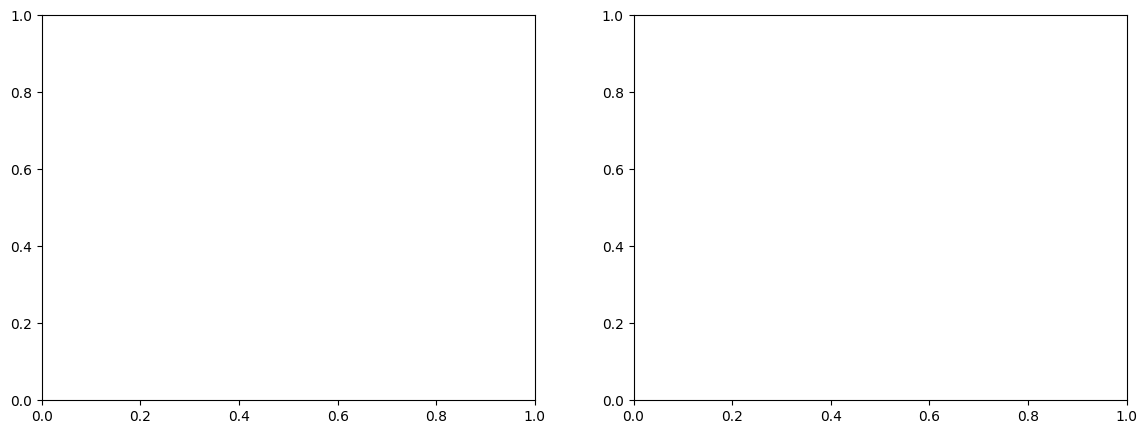

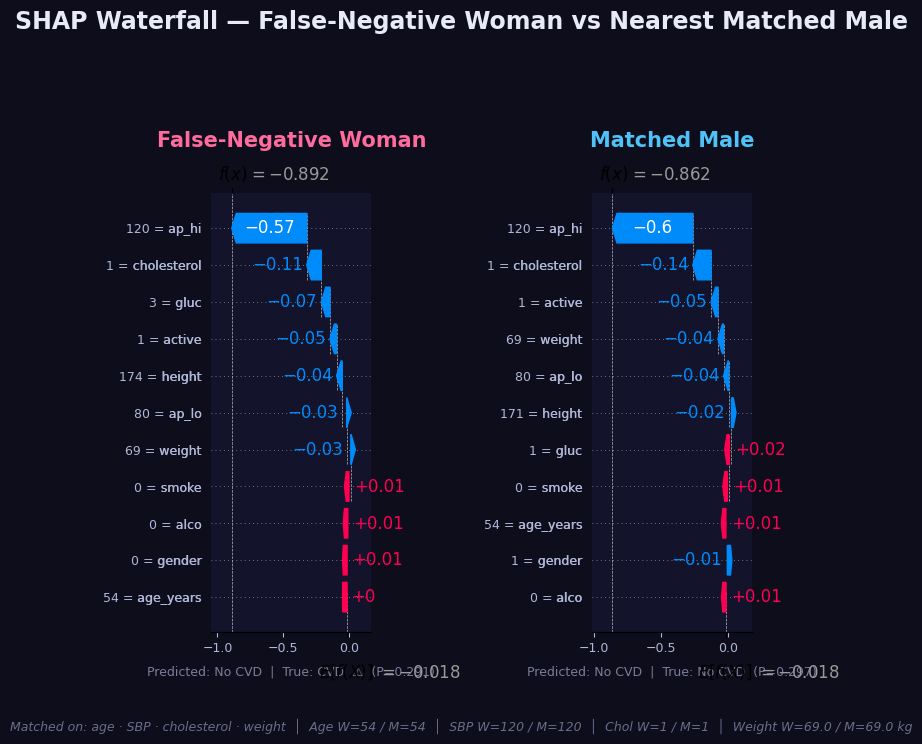


Top SHAP drivers (sorted by |woman SHAP|):
    feature  shap_woman  shap_male  diff (W-M)
      ap_hi     -0.5679    -0.5974     +0.0295
cholesterol     -0.1105    -0.1356     +0.0251
       gluc     -0.0655    +0.0166     -0.0820
     active     -0.0504    -0.0513     +0.0009
     height     -0.0428    -0.0210     -0.0218
      ap_lo     -0.0342    -0.0381     +0.0040
     weight     -0.0309    -0.0415     +0.0106
      smoke     +0.0137    +0.0138     -0.0000
       alco     +0.0088    +0.0095     -0.0006
     gender     +0.0055    -0.0105     +0.0160


In [92]:
# ── Additional code: SHAP False-Negative Analysis ────────────────────────────
# Paste this after your existing model evaluation code
import shap
import numpy as np
from sklearn.preprocessing import StandardScaler


MATCHING_FEATURES = ["age_years", "ap_hi", "cholesterol", "weight"]

# 1. Identify false-negative women (true=1, predicted=0, gender=0)
fn_mask    = (y_test.values == 1) & (y_pred == 0) & (test_df["gender"].values == 0)
fn_women   = test_df[fn_mask].copy()
fn_women_X = X_test[fn_mask].copy()
print(f"False-negative women: {len(fn_women)}")

# 2. Pick most representative FN woman (closest to median profile)
fn_std     = fn_women[MATCHING_FEATURES].std().replace(0, 1)
fn_median  = fn_women[MATCHING_FEATURES].median()
distances  = fn_women[MATCHING_FEATURES].apply(
    lambda row: np.linalg.norm((row - fn_median) / fn_std), axis=1
)
rep_idx     = distances.idxmin()
rep_woman   = fn_women.loc[rep_idx]
rep_woman_X = X_test.loc[rep_idx]

# 3. Find nearest male in test set (z-score normalised L2 distance)
males   = test_df[test_df["gender"] == 1].copy()
males_X = X_test[test_df["gender"].values == 1].copy()

scaler = StandardScaler()
scaler.fit(pd.concat([fn_women[MATCHING_FEATURES], males[MATCHING_FEATURES]]))

woman_scaled = scaler.transform(rep_woman[MATCHING_FEATURES].values.reshape(1, -1))
males_scaled = scaler.transform(males[MATCHING_FEATURES])

best_pos   = np.argmin(np.linalg.norm(males_scaled - woman_scaled, axis=1))
rep_male   = males.iloc[best_pos]
rep_male_X = males_X.iloc[best_pos]

print("\nFeature comparison (woman vs matched male):")
print(pd.DataFrame({
    "FN Woman":     rep_woman[MATCHING_FEATURES].values,
    "Matched Male": rep_male[MATCHING_FEATURES].values,
}, index=MATCHING_FEATURES))

# 4. SHAP explanations
explainer = shap.TreeExplainer(model)
woman_df  = pd.DataFrame(rep_woman_X.values.reshape(1, -1), columns=X_test.columns)
male_df   = pd.DataFrame(rep_male_X.values.reshape(1, -1),  columns=X_test.columns)
sv_woman  = explainer(woman_df)
sv_male   = explainer(male_df)

prob_woman = model.predict_proba(woman_df.values)[0, 1]
prob_male  = model.predict_proba(male_df.values)[0, 1]

# 5. Side-by-side waterfall plots
fig, axes = plt.subplots(1, 2, figsize=(22, 10))
fig.patch.set_facecolor("#0d0d1b")

panels = [
    dict(sv=sv_woman, ax=axes[0], title="False-Negative Woman",
         subtitle=f"Predicted: No CVD  |  True: CVD  ⚠️  (P={prob_woman:.3f})",
         accent="#ff6b9d"),
    dict(sv=sv_male,  ax=axes[1], title="Matched Male",
         subtitle=f"Predicted: {'CVD' if model.predict(male_df.values)[0]==1 else 'No CVD'}  "
                  f"|  True: {'CVD' if rep_male['cardio']==1 else 'No CVD'}  (P={prob_male:.3f})",
         accent="#4fc3f7"),
]

for p in panels:
    plt.sca(p["ax"])
    shap.plots.waterfall(p["sv"][0], max_display=12, show=False)
    p["ax"].set_facecolor("#13132b")
    for spine in p["ax"].spines.values():
        spine.set_edgecolor("#252540")
    p["ax"].tick_params(colors="#b0b8d8", labelsize=9)
    p["ax"].xaxis.label.set_color("#b0b8d8")
    p["ax"].set_title(p["title"], color=p["accent"], fontsize=15, fontweight="bold", pad=12)
    p["ax"].set_xlabel(p["subtitle"], color="#7a7d99", fontsize=9, labelpad=8)

fig.suptitle("SHAP Waterfall — False-Negative Woman vs Nearest Matched Male",
             fontsize=17, fontweight="bold", color="#e8eaf6", y=1.02)
fig.text(0.5, -0.01,
         f"Matched on: age · SBP · cholesterol · weight  │  "
         f"Age W={int(rep_woman['age_years'])} / M={int(rep_male['age_years'])}  │  "
         f"SBP W={int(rep_woman['ap_hi'])} / M={int(rep_male['ap_hi'])}  │  "
         f"Chol W={int(rep_woman['cholesterol'])} / M={int(rep_male['cholesterol'])}  │  "
         f"Weight W={rep_woman['weight']:.1f} / M={rep_male['weight']:.1f} kg",
         ha="center", fontsize=9, color="#6a6d88", style="italic")

plt.tight_layout(pad=3.0)
plt.savefig("shap_fn_woman_vs_matched_male.png", dpi=150,
            bbox_inches="tight", facecolor=fig.get_facecolor())
plt.show()

# 6. Console SHAP driver summary
print("\nTop SHAP drivers (sorted by |woman SHAP|):")
print(pd.DataFrame({
    "feature":    X_test.columns,
    "shap_woman": sv_woman[0].values,
    "shap_male":  sv_male[0].values,
    "diff (W-M)": sv_woman[0].values - sv_male[0].values,
}).sort_values("shap_woman", key=abs, ascending=False).head(10).to_string(
    index=False, float_format="{:+.4f}".format))

In [93]:
# How it is treating gluc = 3 and chol = 3 cases
df_gluc_chol = df_baseline[(df_baseline["gluc"] == 3)  & (df_baseline["cholesterol"] == 3)]

print(f"Total cases (gluc=3, chol=3): {len(df_gluc_chol)}")
print(f"\nCVD rate by gender:")
print(df_gluc_chol.groupby("gender")["cardio"].agg(
    cvd_rate="mean",
    count="count"
).round(3).to_string())

print(f"\nModel predictions for these cases:")
X_gluc_chol = df_gluc_chol.drop(columns=["cardio", "stratify"])
y_gluc_chol = df_gluc_chol["cardio"]
y_pred_gluc_chol = model.predict(X_gluc_chol)

print(pd.DataFrame({
    "gender": df_gluc_chol["gender"].map({0: "Female", 1: "Male"}),
    "true":   y_gluc_chol,
    "pred":   y_pred_gluc_chol,
    "prob":   model.predict_proba(X_gluc_chol)[:, 1].round(3)
}).groupby("gender").agg(
    cvd_rate=("true", "mean"),
    pred_rate=("pred", "mean"),
    mean_prob=("prob", "mean"),
    count=("true", "count")
).round(3).to_string())

Total cases (gluc=3, chol=3): 3365

CVD rate by gender:
        cvd_rate  count
gender                 
0          0.691   2384
1          0.679    981

Model predictions for these cases:
        cvd_rate  pred_rate  mean_prob  count
gender                                       
Female     0.691      0.898      0.698   2384
Male       0.679      0.887      0.699    981


In [94]:
# BP distribution for gluc=3 + chol=3 cases by sex
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, gender, label, color in [
    (axes[0], 0, "Women", "#ff6b9d"),
    (axes[1], 1, "Men",   "#4fc3f7"),
]:
    subset = df_gluc_chol[df_gluc_chol["gender"] == gender]
    
    sns.kdeplot(subset[subset["cardio"]==1]["ap_hi"], 
                ax=ax, color=color, fill=True, alpha=0.4, label="Has CVD")
    sns.kdeplot(subset[subset["cardio"]==0]["ap_hi"], 
                ax=ax, color="grey", fill=True, alpha=0.4, label="No CVD")
    
    ax.axvline(x=110, color="red",   linestyle="--", linewidth=1.5, label="Female threshold")
    ax.axvline(x=130, color="green", linestyle="--", linewidth=1.5, label="Male threshold")
    ax.set_title(f"{label} — gluc=3 + chol=3 BP distribution",
                 color=color, fontweight="bold")
    ax.set_xlabel("ap_hi (mmHg)")
    ax.legend(fontsize=8)
    ax.grid(alpha=0.3)

plt.suptitle("BP Distribution: gluc=3 + chol=3 cases by Sex and CVD status",
             fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

# Also print the CVD rate specifically in 110-130 zone
print("CVD rate for gluc=3 + chol=3 + ap_hi 110-130:")
zone = df_gluc_chol[df_gluc_chol["ap_hi"].between(110, 130)]
print(zone.groupby("gender")["cardio"].agg(
    cvd_rate="mean",
    count="count"
).round(3).to_string())

NameError: name 'sns' is not defined

## Using monotonic clipping on ap_hi 



In [ ]:
X_train_mod = X_train.copy()
X_val_mod   = X_val.copy()
X_test_mod  = X_test.copy()

female_mask_test = test_df["gender"].values == 0
male_mask_test   = test_df["gender"].values == 1

for df in [X_train_mod, X_val_mod, X_test_mod]:
    df["ap_hi"] = df["ap_hi"].clip(lower=100)

feature_list = X_train_mod.columns.tolist()
ap_hi_idx    = feature_list.index("ap_hi")

monotone = [0] * len(feature_list)
monotone[ap_hi_idx] = 1

model_monotone = XGBClassifier(
    n_estimators=500,
    max_depth=4,
    learning_rate=0.05,
    random_state=42,
    early_stopping_rounds=10,
    monotone_constraints=tuple(monotone)
)

model_monotone.fit(
    X_train_mod, y_train,
    eval_set=[(X_val_mod, y_val)],
    verbose=False
)

,"objective objective: typing.Union[str, xgboost.sklearn._SklObjWProto, typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]], NoneType]Specify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'binary:logistic'
,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,None
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",10
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes fr

In [ ]:
from sklearn.metrics import classification_report, roc_auc_score, recall_score
y_pred_mono        = model_monotone.predict(X_test_mod)
y_pred_mono_female = model_monotone.predict(X_test_mod[female_mask_test])
y_pred_mono_male   = model_monotone.predict(X_test_mod[male_mask_test])

print("── Baseline ─────────────────────────────────────────")
print("Overall:")
print(classification_report(y_test, y_pred))
print(f"AUROC: {roc_auc_score(y_test, model.predict_proba(X_test)[:,1]):.3f}")

print("Female:")
print(classification_report(y_test[female_mask_test], y_pred[female_mask_test]))
print(f"AUROC: {roc_auc_score(y_test[female_mask_test], model.predict_proba(X_test[female_mask_test])[:,1]):.3f}")

print("Male:")
print(classification_report(y_test[male_mask_test], y_pred[male_mask_test]))
print(f"AUROC: {roc_auc_score(y_test[male_mask_test], model.predict_proba(X_test[male_mask_test])[:,1]):.3f}")

print("\n── Monotone ap_hi (clipped at 100) ──────────────────")
print("Overall:")
print(classification_report(y_test, y_pred_mono))
print(f"AUROC: {roc_auc_score(y_test, model_monotone.predict_proba(X_test_mod)[:,1]):.3f}")

print("Female:")
print(classification_report(y_test[female_mask_test], y_pred_mono_female))
print(f"AUROC: {roc_auc_score(y_test[female_mask_test], model_monotone.predict_proba(X_test_mod[female_mask_test])[:,1]):.3f}")

print("Male:")
print(classification_report(y_test[male_mask_test], y_pred_mono_male))
print(f"AUROC: {roc_auc_score(y_test[male_mask_test], model_monotone.predict_proba(X_test_mod[male_mask_test])[:,1]):.3f}")

── Baseline ─────────────────────────────────────────
Overall:
              precision    recall  f1-score   support

           0       0.72      0.79      0.75      6880
           1       0.76      0.68      0.72      6756

    accuracy                           0.74     13636
   macro avg       0.74      0.74      0.74     13636
weighted avg       0.74      0.74      0.74     13636

AUROC: 0.801
Female:
              precision    recall  f1-score   support

           0       0.72      0.79      0.76      4492
           1       0.76      0.69      0.72      4374

    accuracy                           0.74      8866
   macro avg       0.74      0.74      0.74      8866
weighted avg       0.74      0.74      0.74      8866

AUROC: 0.807
Male:
              precision    recall  f1-score   support

           0       0.71      0.78      0.74      2388
           1       0.76      0.67      0.71      2382

    accuracy                           0.73      4770
   macro avg       0.73  

In [ ]:
sample_weights = np.ones(len(X_train))

high_risk_cvd = (
    (train_df["cholesterol"].values == 3) &
    (train_df["gluc"].values == 3) &
    # (train_df["ap_hi"] < 130) &
    (y_train.values == 1)  # only where CVD is TRUE
)

print(f"High risk CVD cases in train: {high_risk_cvd.sum()}")

sample_weights[high_risk_cvd] = 50

model_weighted = XGBClassifier(
    n_estimators=500,
    max_depth=4,
    learning_rate=0.05,
    random_state=42,
    early_stopping_rounds=10,
)

model_weighted.fit(
    X_train, y_train,
    sample_weight=sample_weights,
    eval_set=[(X_val, y_val)],
    verbose=False
)

y_pred_w        = model_weighted.predict(X_test)
y_pred_w_female = model_weighted.predict(X_test[female_mask_test])
y_pred_w_male   = model_weighted.predict(X_test[male_mask_test])

print("── Baseline ─────────────────────────────────────────")
print(f"Female recall : {recall_score(y_test[female_mask_test], y_pred[female_mask_test]):.3f}")
print(f"Male recall   : {recall_score(y_test[male_mask_test],   y_pred[male_mask_test]):.3f}")
print(f"AUROC         : {roc_auc_score(y_test, model.predict_proba(X_test)[:,1]):.3f}")

print("\n── Weighted (gluc=3 + chol=3 + CVD=1) ──────────────")
print("Overall:")
print(classification_report(y_test, y_pred_w))
print(f"AUROC: {roc_auc_score(y_test, model_weighted.predict_proba(X_test)[:,1]):.3f}")

print("Female:")
print(classification_report(y_test[female_mask_test], y_pred_w_female))
print(f"AUROC: {roc_auc_score(y_test[female_mask_test], model_weighted.predict_proba(X_test[female_mask_test])[:,1]):.3f}")

print("Male:")
print(classification_report(y_test[male_mask_test], y_pred_w_male))
print(f"AUROC: {roc_auc_score(y_test[male_mask_test], model_weighted.predict_proba(X_test[male_mask_test])[:,1]):.3f}")

High risk CVD cases in train: 1504
── Baseline ─────────────────────────────────────────
Female recall : 0.689
Male recall   : 0.673
AUROC         : 0.801

── Weighted (gluc=3 + chol=3 + CVD=1) ──────────────
Overall:
              precision    recall  f1-score   support

           0       0.72      0.77      0.74      6880
           1       0.75      0.70      0.72      6756

    accuracy                           0.73     13636
   macro avg       0.73      0.73      0.73     13636
weighted avg       0.73      0.73      0.73     13636

AUROC: 0.787
Female:
              precision    recall  f1-score   support

           0       0.73      0.78      0.75      4492
           1       0.75      0.70      0.72      4374

    accuracy                           0.74      8866
   macro avg       0.74      0.74      0.74      8866
weighted avg       0.74      0.74      0.74      8866

AUROC: 0.794
Male:
              precision    recall  f1-score   support

           0       0.71      0.75

In [ ]:
# Only allow ap_hi to interact with bp-related features
# not with gender
interaction_constraints = [
    ["ap_hi", "ap_lo"],           # BP features together
    ["age_years", "gender", "weight", "height"],  # demographic together
    ["cholesterol", "gluc"],      # metabolic together
    ["smoke", "alco", "active"],  # lifestyle together
]

model_constrained = XGBClassifier(
    n_estimators=500,
    max_depth=4,
    learning_rate=0.05,
    random_state=42,
    early_stopping_rounds=10,
    interaction_constraints=interaction_constraints
)

model_constrained.fit(
    X_train, y_train,
    eval_set=[(X_val, y_val)],
    verbose=False
)

,"objective objective: typing.Union[str, xgboost.sklearn._SklObjWProto, typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]], NoneType]Specify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'binary:logistic'
,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,None
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",10
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes fr

In [ ]:



y_pred_con        = model_constrained.predict(X_test)
y_pred_con_female = model_constrained.predict(X_test[female_mask_test])
y_pred_con_male   = model_constrained.predict(X_test[male_mask_test])

from sklearn.metrics import classification_report, roc_auc_score

print("── Baseline ─────────────────────────────────────────")
print(f"Female recall : {recall_score(y_test[female_mask_test], y_pred[female_mask_test]):.3f}")
print(f"Male recall   : {recall_score(y_test[male_mask_test],   y_pred[male_mask_test]):.3f}")
print(f"AUROC         : {roc_auc_score(y_test, model.predict_proba(X_test)[:,1]):.3f}")

print("\n── Constrained model ────────────────────────────────")
print("Overall:")
print(classification_report(y_test, y_pred_con))
print(f"AUROC: {roc_auc_score(y_test, model_constrained.predict_proba(X_test)[:,1]):.3f}")

print("Female:")
print(classification_report(y_test[female_mask_test], y_pred_con_female))
print(f"AUROC: {roc_auc_score(y_test[female_mask_test], model_constrained.predict_proba(X_test[female_mask_test])[:,1]):.3f}")

print("Male:")
print(classification_report(y_test[male_mask_test], y_pred_con_male))
print(f"AUROC: {roc_auc_score(y_test[male_mask_test], model_constrained.predict_proba(X_test[male_mask_test])[:,1]):.3f}")

── Baseline ─────────────────────────────────────────
Female recall : 0.689
Male recall   : 0.673
AUROC         : 0.801

── Constrained model ────────────────────────────────
Overall:
              precision    recall  f1-score   support

           0       0.71      0.80      0.75      6880
           1       0.77      0.66      0.71      6756

    accuracy                           0.73     13636
   macro avg       0.74      0.73      0.73     13636
weighted avg       0.74      0.73      0.73     13636

AUROC: 0.796
Female:
              precision    recall  f1-score   support

           0       0.71      0.80      0.75      4492
           1       0.77      0.66      0.71      4374

    accuracy                           0.74      8866
   macro avg       0.74      0.73      0.73      8866
weighted avg       0.74      0.74      0.73      8866

AUROC: 0.802
Male:
              precision    recall  f1-score   support

           0       0.70      0.80      0.74      2388
           1 

In [ ]:
X_train_pp = X_train.copy()
X_val_pp   = X_val.copy()
X_test_pp  = X_test.copy()

for df in [X_train_pp, X_val_pp, X_test_pp]:
    df["pulse_pressure"] = df["ap_hi"] - df["ap_lo"]
    df["chol_gluc_interact"]  = df["cholesterol"] * df["gluc"]

    df.drop(columns=["ap_hi"], inplace=True)  # drop BOTH
    
interaction_constraints = [
    ["cholesterol", "gluc", "chol_gluc_interact"],
    ["gender", "height", "smoke", "alco"],
    ["age_years", "weight"],
    ["active"],
]

model_pp = XGBClassifier(
    n_estimators=500,
    max_depth=4,
    learning_rate=0.05,
    random_state=42,
    early_stopping_rounds=10,
        interaction_constraints=interaction_constraints

)

model_pp.fit(
    X_train_pp, y_train,
    eval_set=[(X_val_pp, y_val)],
    verbose=False
)

y_pred_pp        = model_pp.predict(X_test_pp)
y_pred_pp_female = model_pp.predict(X_test_pp[female_mask_test])
y_pred_pp_male   = model_pp.predict(X_test_pp[male_mask_test])

from sklearn.metrics import classification_report, roc_auc_score, recall_score

print("── Baseline ─────────────────────────────────────────")
print(f"Female recall : {recall_score(y_test[female_mask_test], y_pred[female_mask_test]):.3f}")
print(f"Male recall   : {recall_score(y_test[male_mask_test],   y_pred[male_mask_test]):.3f}")
print(f"AUROC         : {roc_auc_score(y_test, model.predict_proba(X_test)[:,1]):.3f}")

print("\n── Pulse Pressure model (ap_lo removed) ─────────────")
print("Overall:")
print(classification_report(y_test, y_pred_pp))
print(f"AUROC: {roc_auc_score(y_test, model_pp.predict_proba(X_test_pp)[:,1]):.3f}")

print("Female:")
print(classification_report(y_test[female_mask_test], y_pred_pp_female))
print(f"AUROC: {roc_auc_score(y_test[female_mask_test], model_pp.predict_proba(X_test_pp[female_mask_test])[:,1]):.3f}")

print("Male:")
print(classification_report(y_test[male_mask_test], y_pred_pp_male))
print(f"AUROC: {roc_auc_score(y_test[male_mask_test], model_pp.predict_proba(X_test_pp[male_mask_test])[:,1]):.3f}")

── Baseline ─────────────────────────────────────────
Female recall : 0.689
Male recall   : 0.673
AUROC         : 0.801

── Pulse Pressure model (ap_lo removed) ─────────────
Overall:
              precision    recall  f1-score   support

           0       0.71      0.79      0.75      6880
           1       0.76      0.67      0.71      6756

    accuracy                           0.73     13636
   macro avg       0.73      0.73      0.73     13636
weighted avg       0.73      0.73      0.73     13636

AUROC: 0.793
Female:
              precision    recall  f1-score   support

           0       0.71      0.79      0.75      4492
           1       0.76      0.67      0.71      4374

    accuracy                           0.73      8866
   macro avg       0.73      0.73      0.73      8866
weighted avg       0.73      0.73      0.73      8866

AUROC: 0.800
Male:
              precision    recall  f1-score   support

           0       0.70      0.78      0.74      2388
           1 

In [ ]:

# # ── 3. Compare before/after on test set ──────────────────────────────────────
# from sklearn.metrics import classification_report, roc_auc_score



# print("\n── Baseline model ───────────────────────────────────────")
# print("Female:")
# print(classification_report(y_test[female_mask_test], y_pred[female_mask_test]))
# print("Male:")
# print(classification_report(y_test[male_mask_test], y_pred[male_mask_test]))

# print("\n── Weighted model ───────────────────────────────────────")
# print("Female:")
# print(classification_report(y_test[female_mask_test], y_pred_weighted_female))
# print("Male:")
# print(classification_report(y_test[male_mask_test], y_pred_weighted_male))

# # ── 4. AUROC comparison ───────────────────────────────────────────────────────
# prob_weighted_female = model_weighted.predict_proba(X_test[female_mask_test])[:, 1]
# prob_weighted_male   = model_weighted.predict_proba(X_test[male_mask_test])[:, 1]

# print(f"\nBaseline  Female AUROC : {roc_auc_score(y_test[female_mask_test], model.predict_proba(X_test[female_mask_test])[:, 1]):.3f}")
# print(f"Weighted  Female AUROC : {roc_auc_score(y_test[female_mask_test], prob_weighted_female):.3f}")
# print(f"\nBaseline  Male AUROC   : {roc_auc_score(y_test[male_mask_test], model.predict_proba(X_test[male_mask_test])[:, 1]):.3f}")
# print(f"Weighted  Male AUROC   : {roc_auc_score(y_test[male_mask_test], prob_weighted_male):.3f}")

# # ── 5. Check edge cases specifically ─────────────────────────────────────────
# edge_case_test = (
#     (test_df["gender"].values == 0) &
#     (test_df["ap_hi"].between(110, 130)) &
#     (test_df["gluc"].values == 3) &
#     (test_df["cholesterol"].values == 3)
# )

# print(f"\nEdge cases in test set: {edge_case_test.sum()}")
# print(f"Baseline  recall on edge cases : {(y_pred[edge_case_test] == y_test.values[edge_case_test]).mean():.3f}")
# print(f"Weighted  recall on edge cases : {(model_weighted.predict(X_test[edge_case_test]) == y_test.values[edge_case_test]).mean():.3f}")

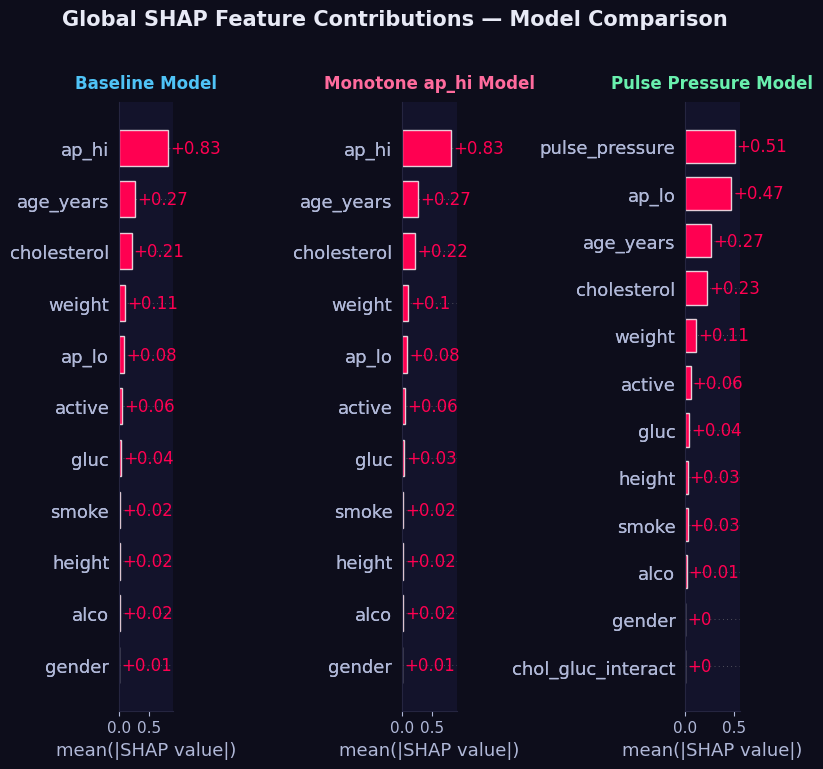

In [ ]:
import shap
import matplotlib.pyplot as plt

# ── SHAP explainers for each model ───────────────────────────────────────────
explainer_base = shap.TreeExplainer(model)
explainer_mono = shap.TreeExplainer(model_monotone)
explainer_pp   = shap.TreeExplainer(model_pp)

sv_base = explainer_base(X_test)
sv_mono = explainer_mono(X_test_mod)
sv_pp   = explainer_pp(X_test_pp)

# ── Plot ──────────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(24, 8))

models = [
    dict(sv=sv_base, ax=axes[0], title="Baseline Model",        color="#4fc3f7"),
    dict(sv=sv_mono, ax=axes[1], title="Monotone ap_hi Model",  color="#ff6b9d"),
    dict(sv=sv_pp,   ax=axes[2], title="Pulse Pressure Model",  color="#69f0ae"),
]

for m in models:
    plt.sca(m["ax"])
    shap.plots.bar(m["sv"], max_display=12, show=False)
    m["ax"].set_title(m["title"], color=m["color"],
                      fontsize=12, fontweight="bold", pad=10)
    m["ax"].set_facecolor("#13132b")
    for spine in m["ax"].spines.values():
        spine.set_edgecolor("#252540")
    m["ax"].tick_params(colors="#b0b8d8")
    m["ax"].xaxis.label.set_color("#b0b8d8")
    fig.patch.set_facecolor("#0d0d1b")

fig.suptitle("Global SHAP Feature Contributions — Model Comparison",
             fontsize=15, fontweight="bold", color="#e8eaf6", y=1.02)

plt.tight_layout()
plt.savefig("shap_global_model_comparison.png", dpi=150,
            bbox_inches="tight", facecolor="#0d0d1b")
plt.show()

In [ ]:
# Apply feature engineering
X_train_fe = X_train.copy()
X_val_fe   = X_val.copy()
X_test_fe  = X_test.copy()

for df in [X_train_fe, X_val_fe, X_test_fe]:
    df["pulse_pressure"]       = df["ap_hi"] - df["ap_lo"]
    df["chol_gluc_interact"]   = df["cholesterol"] * df["gluc"]
    df["metabolic_risk_score"] = (df["cholesterol"] - 1) + (df["gluc"] - 1)
    df["high_metabolic_risk"]  = ((df["cholesterol"]==3) & (df["gluc"]==3)).astype(int)
    df.drop(columns=["ap_lo"], inplace=True)

# Save AFTER feature engineering with labels
train_fe_save = X_train_fe.copy()
val_fe_save   = X_val_fe.copy()
test_fe_save  = X_test_fe.copy()

train_fe_save["cardio"]   = y_train.values

val_fe_save["cardio"]     = y_val.values

test_fe_save["cardio"]    = y_test.values

train_fe_save.to_csv("../data/test_train_val_sets/cardio_fe_train.csv", index=False)
val_fe_save.to_csv("../data/test_train_val_sets/cardio_fe_val.csv",     index=False)
test_fe_save.to_csv("../data/test_train_val_sets/cardio_fe_test.csv",   index=False)

print("Saved FE splits:")
print(f"Cols: {train_fe_save.columns.tolist()}")

model_fe = XGBClassifier(
    n_estimators=500,
    max_depth=4,
    learning_rate=0.05,
    random_state=42,
    early_stopping_rounds=10,
    scale_pos_weight=1.5,
)

model_fe.fit(
    X_train_fe, y_train,
    eval_set=[(X_val_fe, y_val)],
    verbose=False
)

# Save model
with open("refined_models/cardio_xgb_fe_model.pkl", "wb") as f:
    pickle.dump(model_fe, f)



print("Saved model and test set")
print(f"Features: {X_test_fe.columns.tolist()}")

Saved FE splits:
Cols: ['gender', 'height', 'weight', 'ap_hi', 'cholesterol', 'gluc', 'smoke', 'alco', 'active', 'age_years', 'pulse_pressure', 'chol_gluc_interact', 'metabolic_risk_score', 'high_metabolic_risk', 'cardio']
Saved model and test set
Features: ['gender', 'height', 'weight', 'ap_hi', 'cholesterol', 'gluc', 'smoke', 'alco', 'active', 'age_years', 'pulse_pressure', 'chol_gluc_interact', 'metabolic_risk_score', 'high_metabolic_risk']


In [ ]:
# X_train_fe = X_train.copy()
# X_val_fe   = X_val.copy()
# X_test_fe  = X_test.copy()

# for df in [X_train_fe, X_val_fe, X_test_fe]:
#     df["pulse_pressure"]     = df["ap_hi"] - df["ap_lo"]
#     df["chol_gluc_interact"] = df["cholesterol"] * df["gluc"]
#     df.drop(columns=["ap_lo"], inplace=True)
#     df["metabolic_risk_score"] = (
#         (df["cholesterol"] - 1) +    # 0,1,2
#         (df["gluc"] - 1)             # 0,1,2
#     )                                # max = 4, min = 0

#     # High risk flag
#     df["high_metabolic_risk"] = (
#         (df["cholesterol"] == 3) & 
#         (df["gluc"] == 3)
#     ).astype(int)

# print("New feature set:")
# print(X_train_fe.columns.tolist())

# model_fe = XGBClassifier(
#     n_estimators=500,
#     max_depth=4,
#     learning_rate=0.05,
#     random_state=42,
#     early_stopping_rounds=10,
#     scale_pos_weight=1.5,    # upweight positive class globally

# )

# model_fe.fit(
#     X_train_fe, y_train,
#     eval_set=[(X_val_fe, y_val)],
#     verbose=False
# )

y_pred_fe        = model_fe.predict(X_test_fe)
y_pred_fe_female = model_fe.predict(X_test_fe[female_mask_test])
y_pred_fe_male   = model_fe.predict(X_test_fe[male_mask_test])


print("── Baseline ─────────────────────────────────────────")
print(f"Female recall : {recall_score(y_test[female_mask_test], y_pred[female_mask_test]):.3f}")
print(f"Male recall   : {recall_score(y_test[male_mask_test],   y_pred[male_mask_test]):.3f}")
print(f"AUROC         : {roc_auc_score(y_test, model.predict_proba(X_test)[:,1]):.3f}")

print("\n── Binned ap_hi + PP + Chol*Gluc ────────────────────")
print("Overall:")
print(classification_report(y_test, y_pred_fe))
print(f"AUROC: {roc_auc_score(y_test, model_fe.predict_proba(X_test_fe)[:,1]):.3f}")

print("Female:")
print(classification_report(y_test[female_mask_test], y_pred_fe_female))
print(f"AUROC: {roc_auc_score(y_test[female_mask_test], model_fe.predict_proba(X_test_fe[female_mask_test])[:,1]):.3f}")

print("Male:")
print(classification_report(y_test[male_mask_test], y_pred_fe_male))
print(f"AUROC: {roc_auc_score(y_test[male_mask_test], model_fe.predict_proba(X_test_fe[male_mask_test])[:,1]):.3f}")



── Baseline ─────────────────────────────────────────
Female recall : 0.689
Male recall   : 0.673
AUROC         : 0.801

── Binned ap_hi + PP + Chol*Gluc ────────────────────
Overall:
              precision    recall  f1-score   support

           0       0.76      0.68      0.71      6880
           1       0.70      0.78      0.74      6756

    accuracy                           0.73     13636
   macro avg       0.73      0.73      0.73     13636
weighted avg       0.73      0.73      0.73     13636

AUROC: 0.800
Female:
              precision    recall  f1-score   support

           0       0.77      0.68      0.72      4492
           1       0.71      0.79      0.74      4374

    accuracy                           0.73      8866
   macro avg       0.74      0.73      0.73      8866
weighted avg       0.74      0.73      0.73      8866

AUROC: 0.806
Male:
              precision    recall  f1-score   support

           0       0.74      0.67      0.70      2388
           1 

KeyError: 'ap_lo'